In [1]:
# Loading all libraries
import numpy as np
import pandas as pd
import seaborn as sns
from os import getcwd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
from xgboost import XGBClassifier
from functions_gef import *
import warnings
warnings.filterwarnings("ignore")

In [2]:
path="../UAI/datasets/"

In [122]:
datasets = ['robot',
            'students'
            ]

In [123]:
# Config
B=15
k_cv=5
correct=True
p=0.7

In [124]:
rob_dict_all={}
for ds in datasets:
    print(ds)
    # Loading the dataset
    df = pd.read_csv(path+ds+".csv")
    y=df.loc[:,df.columns[-1]]
    if y.dtype == 'object':
        y = pd.Categorical(y).codes
    elif y.dtype=='int':
        y = y-y.min()
    X=df.loc[:,df.columns[:-1]]
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = pd.Categorical(X[col]).codes
    
    # Turn X into a dataframe in case it is not to infer dtype
    X=pd.DataFrame(X)
    ncat = np.ones(X.shape[1]+1) # This assumes all features are continuous
    
    # Changing the features for discrete if necessary
    X_type=np.array(X.dtypes)
    matchings_indices = [ i for i, x in enumerate(X_type) if x not in ['float','int'] ]
    for i in matchings_indices:
        ncat[i]=len(np.unique(X[X.columns[i]]))
    
    # Convert to numpy arrays if not already
    y = np.asarray(y)
    X = np.asarray(X)
    
    # Defining models
    ## Gradient Boosting
    gb = GradientBoostingClassifier(random_state = 8)
    param_grid = {
        'learning_rate': [0.1, 0.2],
        'n_estimators': [100, 200]
    }
    gb_grid = GridSearchCV(gb, param_grid, cv=k_cv, scoring='neg_log_loss', n_jobs = -1)
    ## Random Forest
    rf = RandomForestClassifier(random_state = 7)
    param_grid = {
        'n_estimators': [100, 200],
        'max_features': ['sqrt', 'log2'],
        'max_depth': [5, None],
        'min_samples_split': [2, 5]
    }
    rf_grid = GridSearchCV(rf, param_grid, cv=k_cv, scoring='neg_log_loss', n_jobs = -1)
    ## XGBoost
    xgb = XGBClassifier(n_jobs = None, random_state = 6)
    param_grid = {
        'max_depth': [5, 7],
        'learning_rate': [0.1, 0.01],
        'subsample': [0.5, 1]
    }
    xgb_grid = GridSearchCV(xgb, param_grid, cv=k_cv, scoring='neg_log_loss', n_jobs = 1)
    
    cats=np.sort(np.unique(y))
    ncat[-1] = len(cats)
    
    # Initialize lists to store results
    gb_rob_list = []
    rf_rob_list = []
    xgb_rob_list = []
    gef_rob_list = []
    
    gb_class_list = []
    rf_class_list = []
    xgb_class_list = []
    gef_class_list = []

    for i in range(B):
        # Step 1: Random sample without replacement of size n (with train/test splitting)
        X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=p,random_state= i)
        
        # Step 3: Fit the model on training data and transform it into a GeF
        gb_grid.fit(X_train,y_train)
        rf_grid.fit(X_train,y_train)
        xgb_grid.fit(X_train,y_train)
        mod=rf_grid.best_estimator_
        gef = rf2pc(mod, X_train, y_train, ncat, learnspn=np.Inf, minstd=1., smoothing=1e-6)
        
        gb_rob_list.append(ratio_robustness(np.log(gb_grid.predict_proba(X_test))))
        rf_rob_list.append(ratio_robustness(np.log(rf_grid.predict_proba(X_test))))
        xgb_rob_list.append(ratio_robustness(np.log(xgb_grid.predict_proba(X_test))))
        gef_rob_list.append(ratio_robustness(gef_logprobs(X_test, cats, gef)))
        
        preds, pred_prob = gef.classify(X_test, return_prob=True)
        
        gb_class_list.append((y_test == gb_grid.predict(X_test))*1)
        rf_class_list.append((y_test == rf_grid.predict(X_test))*1)
        xgb_class_list.append((y_test == xgb_grid.predict(X_test))*1)
        gef_class_list.append((y_test == preds)*1)
        
    # Step 4: Calculate metrics
    dict_rob = {"Gradient Boosting": np.array(gb_rob_list),
                "Random Forest": np.array(rf_rob_list),
                "XGBoost": np.array(xgb_rob_list),
                "Generative Forest": np.array(gef_rob_list) 
                }
    dict_class = {"Gradient Boosting": np.array(gb_class_list),
                  "Random Forest": np.array(rf_class_list),
                  "XGBoost": np.array(xgb_class_list),
                  "Generative Forest": np.array(gef_class_list)
                 }
    
    rob_dict_all[ds]={"rob": dict_rob, "class": dict_class}

robot
gesture


KeyboardInterrupt: 

In [202]:
DB = 'vowel'

In [209]:
Colors = ['tab:blue', 'tab:green', 'tab:red', 'tab:purple', 'tab:orange', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']
rob_measures = rob_dict_all[DB]["rob"]
classification_results = rob_dict_all[DB]["class"]
fig_size=(16,10)
mean=True
stddev=False
keys=None
percentiles=None
show=True
title_extra=""
folder=None
y_min=0.7
legend_loc='lower right'
colors=Colors
AUC=True


AUC:  0.8836781351242083

AUC:  0.9492444548933031

AUC:  0.8989992548849177

AUC:  0.8741437932776807


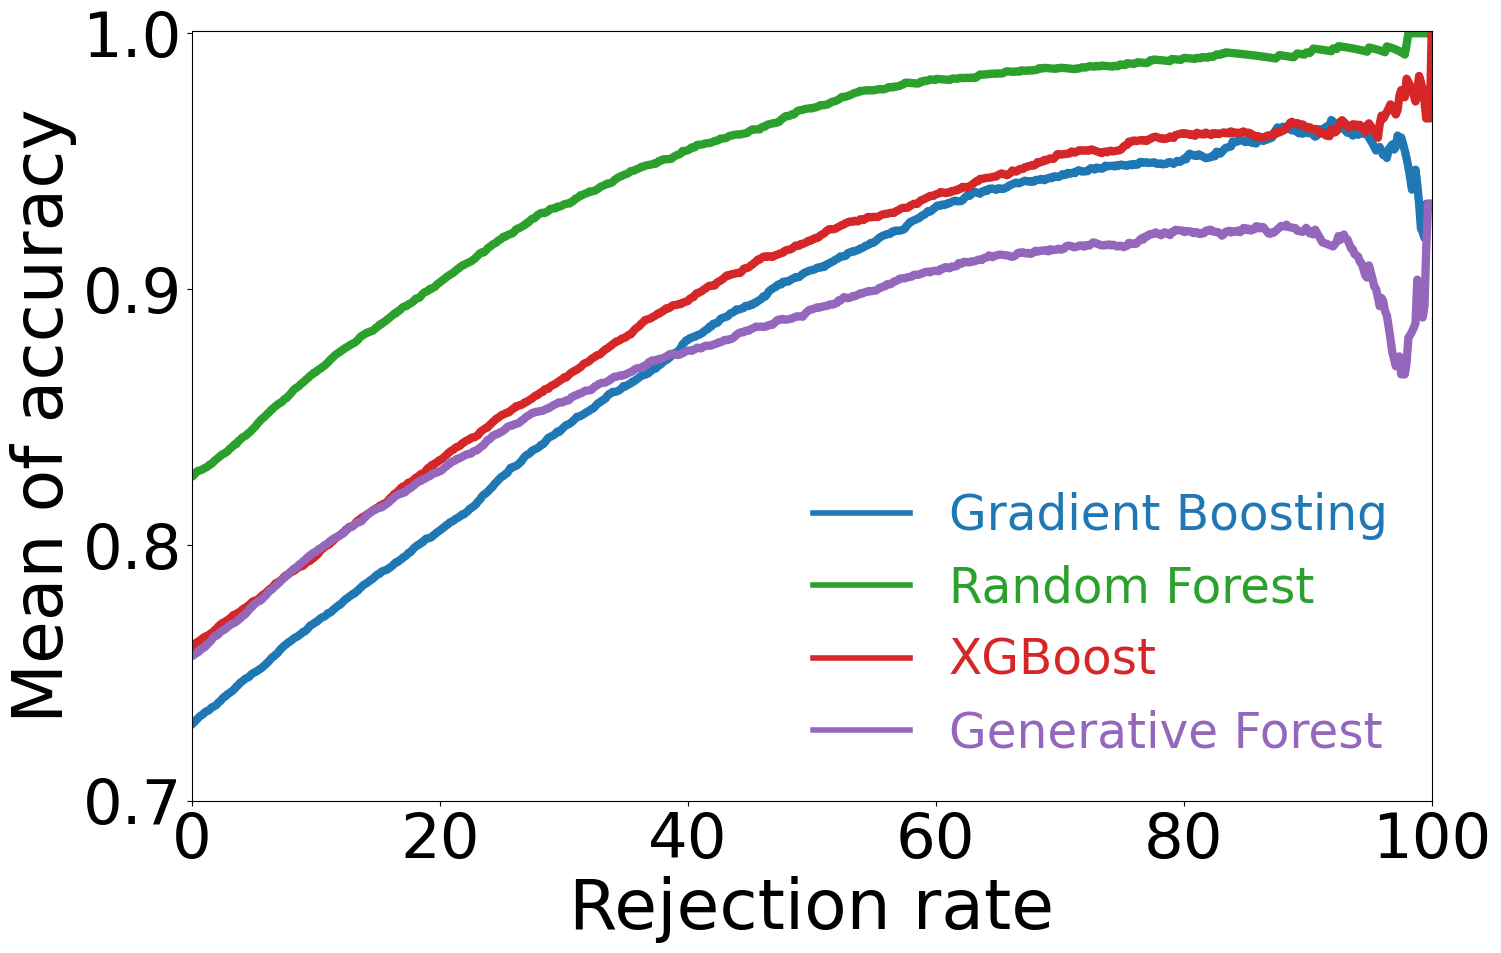

In [210]:
fig, axs = plt.subplots(1, 1, figsize=fig_size)
axs = [axs]

counter = 0
for rob_key in rob_measures:
    if keys is not None:
        if rob_key not in keys:
            continue

    accuracy_rejection_curve(rob_measures[rob_key], classification_results[rob_key],  ax=axs[0], set_name=None, percentiles=percentiles, color=colors[counter], mean=mean, stddev=stddev, AUC=AUC)
    counter += 1

# titles and legends of the subplots
# axs[0].set_title("All points")
if keys is not None:
    l = keys
else:
    l = list(rob_measures.keys())

axs[0].legend(l, labelcolor=colors, loc=legend_location, prop={'size': 40}, frameon=False, bbox_to_anchor=(-.01,1.05))
axs[0].xaxis.label.set_size(50)
axs[0].yaxis.label.set_size(50)
axs[0].tick_params(axis='both', labelsize=45)
    
legend_location = legend_loc
plt.ylim(y_min, 1.001)

if legend_loc != 'empty':
    if colors is not None:
        axs[0].legend(l, labelcolor=colors, loc=legend_location)
        leg = axs[0].get_legend()
        for i in range(len(l)):
            leg.legendHandles[i].set_color(colors[i])
    else:
        axs[0].legend(l, loc=legend_location)
        
axs[0].legend(l, labelcolor=colors, loc=legend_location, prop={'size': 35}, frameon=False)
        
leg = axs[0].get_legend()
for i in range(len(l)):
    leg.legendHandles[i].set_color(colors[i])
    leg.legendHandles[i].set_linewidth(4)
for line in axs[0].lines:
    line.set_linewidth(6)  # Set all lines to width 2.5
        
# plt.tight_layout()
plt.xlim(0, 100)

plt.show()

In [184]:
# Saving the essential information of the analysis
import pickle

with open('rob_mods.pickle', 'wb') as handle:
    pickle.dump(rob_dict_all, handle, protocol=pickle.HIGHEST_PROTOCOL)




AUC:  0.8836781351242083

AUC:  0.9492444548933031

AUC:  0.8989992548849177

AUC:  0.8741437932776807


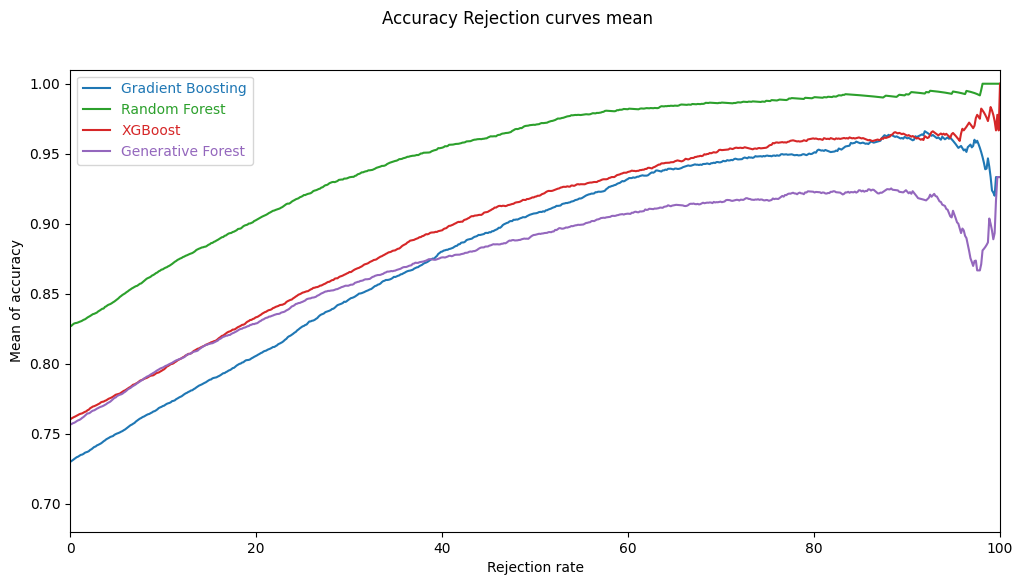

In [98]:
models_acc_rej(rob_measures = rob_dict_all[DB]["rob"], classification_results = rob_dict_all[DB]["class"],
               fig_size=(12,6), mean=True, show=True, y_min=0.68, y_max=1.1, legend_loc='upper left',
               colors=Colors, AUC=True)

In [38]:
DB = 'waveform_21'



AUC:  0.9536673913947789

AUC:  0.9564515113059928

AUC:  0.9582688007030686

AUC:  0.9605924189492826


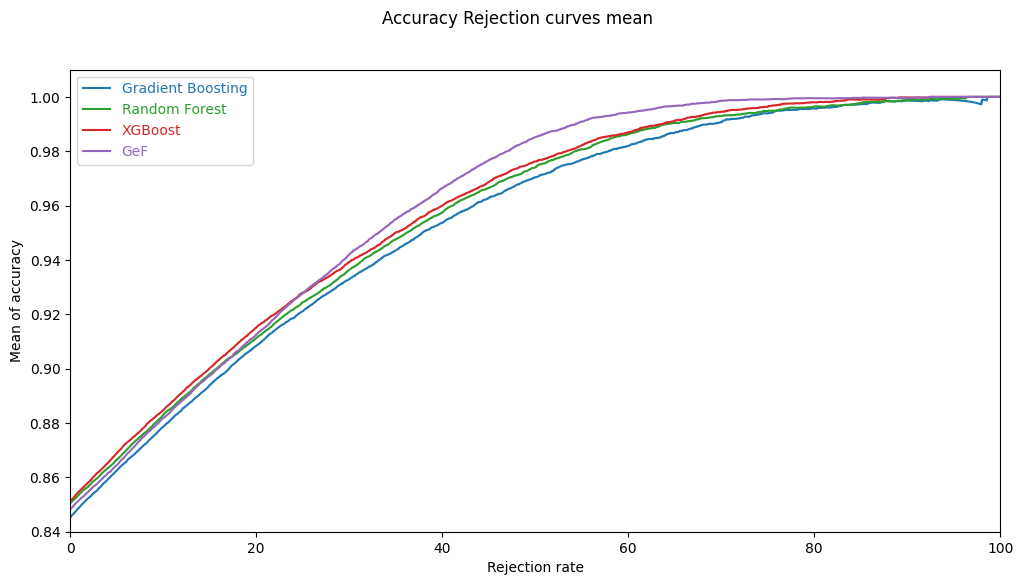

In [14]:
models_acc_rej(rob_measures = rob_dict_all[DB]["rob"], classification_results = rob_dict_all[DB]["class"],
               fig_size=(12,6), mean=True, show=True, y_min=0.84, y_max=1.1, legend_loc='upper left',
               colors=Colors, AUC=True)